In [1]:
import onep
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy
%matplotlib inline

In [2]:
# Mice grouped by sex and ID
female_mice = [f"astroF{i}" for i in [3, 5, 6, 7, 8, 9, 10]]
male_mice = [f"astroM{i}" for i in range(3, 11)]

# Combine and tag sex
all_mice = [{'id': m, 'sex': 'F'} for m in female_mice] + [{'id': m, 'sex': 'M'} for m in male_mice]

In [5]:
import os

def load_sessions(mice, session, base_path, verbose=True):
    objects = {}
    for mouse in mice:
        m_id = mouse['id']
        try:
            if verbose:
                print(f"Loading: {m_id} | Session: {session}")

            proc = onep.InscopixProcessing(m_id, session, base_path)

            # Check for expected AnyMaze file
            if not os.path.isfile(proc.anymaze):
                if verbose:
                    print(f"Missing AnyMaze file for {m_id}, skipping.")
                continue

            proc.read_inscopix()
            proc.run_behavior_analysis()
            objects[m_id] = proc

        except Exception as e:
            print(f"Error processing {m_id}: {e}")
            continue

    return objects

def get_binned_freezing(mouse_objects):
    dfs = []
    for m_id, proc in mouse_objects.items():
        df = proc.binned_freezing.copy()
        df['Mouse'] = m_id
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

In [3]:
sessions = ['hab','fc','cxta','cxtb']
data_path = r"/Volumes/rsenne/dCA1_Clean_Data"
mouse_data = {}

for sess in sessions:
    mouse_data[sess] = load_sessions(all_mice, sess, data_path)
    df = get_binned_freezing(mouse_data[sess])
    df.to_csv(f'/Users/suthardr/Desktop/{sess}_freezing.csv', index=False)


NameError: name 'load_sessions' is not defined

### Plot freezing percentages - average and across_time

In [4]:
#import data
import pandas as pd

# Load your exported CSV
df_hab = pd.read_csv(r"/Volumes/rkc_ramirezlab/Home/rsenne/dCA1_Clean_Data/Anymaze/hab_freezing.csv")
df_hab['Session'] = 'HAB'

df_fc = pd.read_csv(r"/Volumes/rkc_ramirezlab/Home/rsenne/dCA1_Clean_Data/Anymaze/fc_freezing.csv")
df_fc['Session'] = 'FC'

df_A = pd.read_csv(r"/Volumes/rkc_ramirezlab/Home/rsenne/dCA1_Clean_Data/Anymaze/cxta_freezing.csv")
df_A['Session'] = 'A'

df_B = pd.read_csv(r"/Volumes/rkc_ramirezlab/Home/rsenne/dCA1_Clean_Data/Anymaze/cxtb_freezing.csv")
df_B['Session'] = 'B'

In [5]:
mouse_to_group = {
    'astroM3': 'A-B',
    'astroM4': 'A-B',
    'astroM5': 'A-B',
    'astroM6': 'B-A',
    'astroM7': 'B-A',
    'astroM8': 'B-A',
    'astroM9': 'A-B',
    'astroM10': 'A-B',
    'astroF3': 'B-A',
    'astroF5': 'B-A',
    'astroF6': 'A-B',
    'astroF7': 'A-B',
    'astroF8': 'B-A',
    'astroF9': 'B-A',
    'astroF10': 'B-A'
}

In [6]:
sex_to_group = {
    'astroM3': 'Male',
    'astroM4': 'Male',
    'astroM5': 'Male',
    'astroM6': 'Male',
    'astroM7': 'Male',
    'astroM8': 'Male',
    'astroM9': 'Male',
    'astroM10': 'Male',
    'astroF3': 'Female',
    'astroF5': 'Female',
    'astroF6': 'Female',
    'astroF7': 'Female',
    'astroF8': 'Female',
    'astroF9': 'Female',
    'astroF10': 'Female'
}

In [7]:
for df in [df_fc, df_A, df_B, df_hab]:
    df['Sex'] = df['Mouse'].map(sex_to_group)

In [8]:
for df in [df_fc, df_A, df_B, df_hab]:
    df['Group'] = df['Mouse'].map(mouse_to_group)

In [9]:
# Average freezing per mouse and session
df_fc_avg = df_fc.groupby(['Mouse', 'Session', 'Group', 'Sex'])['freezing_percentage'].mean().reset_index()
df_A_avg = df_A.groupby(['Mouse', 'Session', 'Group', 'Sex'])['freezing_percentage'].mean().reset_index()
df_B_avg = df_B.groupby(['Mouse', 'Session', 'Group', 'Sex'])['freezing_percentage'].mean().reset_index()
df_hab_avg = df_hab.groupby(['Mouse', 'Session', 'Group', 'Sex'])['freezing_percentage'].mean().reset_index()

# Combine if desired
df_avg_all = pd.concat([df_fc_avg, df_A_avg, df_B_avg, df_hab_avg])


In [10]:
df_avg_all

,Mouse,Session,Group,Sex,freezing_percentage
0,astroF10,FC,B-A,Female,51.382857
1,astroF3,FC,B-A,Female,18.827143
2,astroF5,FC,B-A,Female,21.570238
3,astroF6,FC,A-B,Female,17.299048
4,astroF7,FC,A-B,Female,10.227381
5,astroF8,FC,B-A,Female,28.673333
6,astroF9,FC,B-A,Female,35.551905
7,astroM10,FC,A-B,Male,37.745238
8,astroM3,FC,A-B,Male,26.909167
9,astroM4,FC,A-B,Male,7.724722


In [11]:
#Clean up data
# Clean column types
df_avg_all['freezing_percentage'] = pd.to_numeric(df_avg_all['freezing_percentage'], errors='coerce')
df_avg_all = df_avg_all.dropna(subset=['freezing_percentage'])

# Make sure categorical columns are strings
df_avg_all['Group'] = df_avg_all['Group'].astype(str)
df_avg_all['Session'] = df_avg_all['Session'].astype(str)
df_avg_all['Mouse'] = df_avg_all['Mouse'].astype(str)
df_avg_all['Sex'] = df_avg_all['Sex'].astype(str)

In [12]:
df_avg_all

,Mouse,Session,Group,Sex,freezing_percentage
0,astroF10,FC,B-A,Female,51.382857
1,astroF3,FC,B-A,Female,18.827143
2,astroF5,FC,B-A,Female,21.570238
3,astroF6,FC,A-B,Female,17.299048
4,astroF7,FC,A-B,Female,10.227381
5,astroF8,FC,B-A,Female,28.673333
6,astroF9,FC,B-A,Female,35.551905
7,astroM10,FC,A-B,Male,37.745238
8,astroM3,FC,A-B,Male,26.909167
9,astroM4,FC,A-B,Male,7.724722


In [16]:
import matplotlib.pyplot as plt

def plot_avg_freezing(df, title="", save_path=None):
    import seaborn as sns
    import matplotlib.pyplot as plt

    sns.set(style="ticks", font="Arial")
    colors = ["#66C1A6", "black"]
    plt.rcParams.update({'font.size': 8})

    fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=600)
    sns.set_palette(sns.color_palette(colors))

    sns.barplot(
        x='Session', y='freezing_percentage', hue='Group', data=df,
        order=['HAB', 'FC', "A", "B"],
        ci=68, capsize=.2, errwidth=1, alpha=0.8, ax=ax
    )

    sns.stripplot(
        x='Session', y='freezing_percentage', hue='Group', data=df,
        dodge=True, jitter=False, linewidth=0.3, edgecolor='black', size=4,
        order=['HAB', 'FC', "A", "B"], ax=ax
    )

    # Clean legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title='Group', loc='upper right',
              fontsize=7, title_fontsize=8, frameon=False)

    ax.set_ylabel('Freezing (%)', fontsize=10)
    ax.set_xlabel('', fontsize=10)
    ax.tick_params(labelsize=8)
    ax.set_ylim(0, 100)
    ax.set_title(title, fontsize=10, pad=10)
    sns.despine()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight', format='svg')
    plt.show()
    return fig, ax

def plot_freezing_across_time(df, title="", save_path=None):
    import seaborn as sns
    import matplotlib.pyplot as plt

    sns.set(style="ticks", font="Arial")
    colors = ["#66C1A6", "black"]
    plt.rcParams.update({'font.size': 8})

    fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=600)
    sns.set_palette(sns.color_palette(colors))

    sns.pointplot(x='bin', y='freezing_percentage', hue='Group', data=df,
                  errorbar='se', ax=ax)

    # sns.stripplot(x='bin', y='freezing_percentage', hue='Group', data=df,
    #               jitter=False, size=4, linewidth=0.3, edgecolor='black',
    #               dodge=True, ax=ax)

    ax.set_ylabel("Freezing (%)", fontsize=10)
    ax.set_xlabel("Time (s)", fontsize=10)
    ax.tick_params(labelsize=8)
    ax.set_ylim(0, 100)
    ax.set_title(title, fontsize=10, pad=10)

    # Optional: Replace x labels with time in seconds
    custom_labels = [0, 60, 120, 180, 240, 300, 330]
    ax.set_xticks(range(len(custom_labels)))
    ax.set_xticklabels(custom_labels)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title='Group', loc='upper right',
              fontsize=7, title_fontsize=8, frameon=False)

    sns.despine()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight', format='svg')
    plt.show()
    return fig, ax


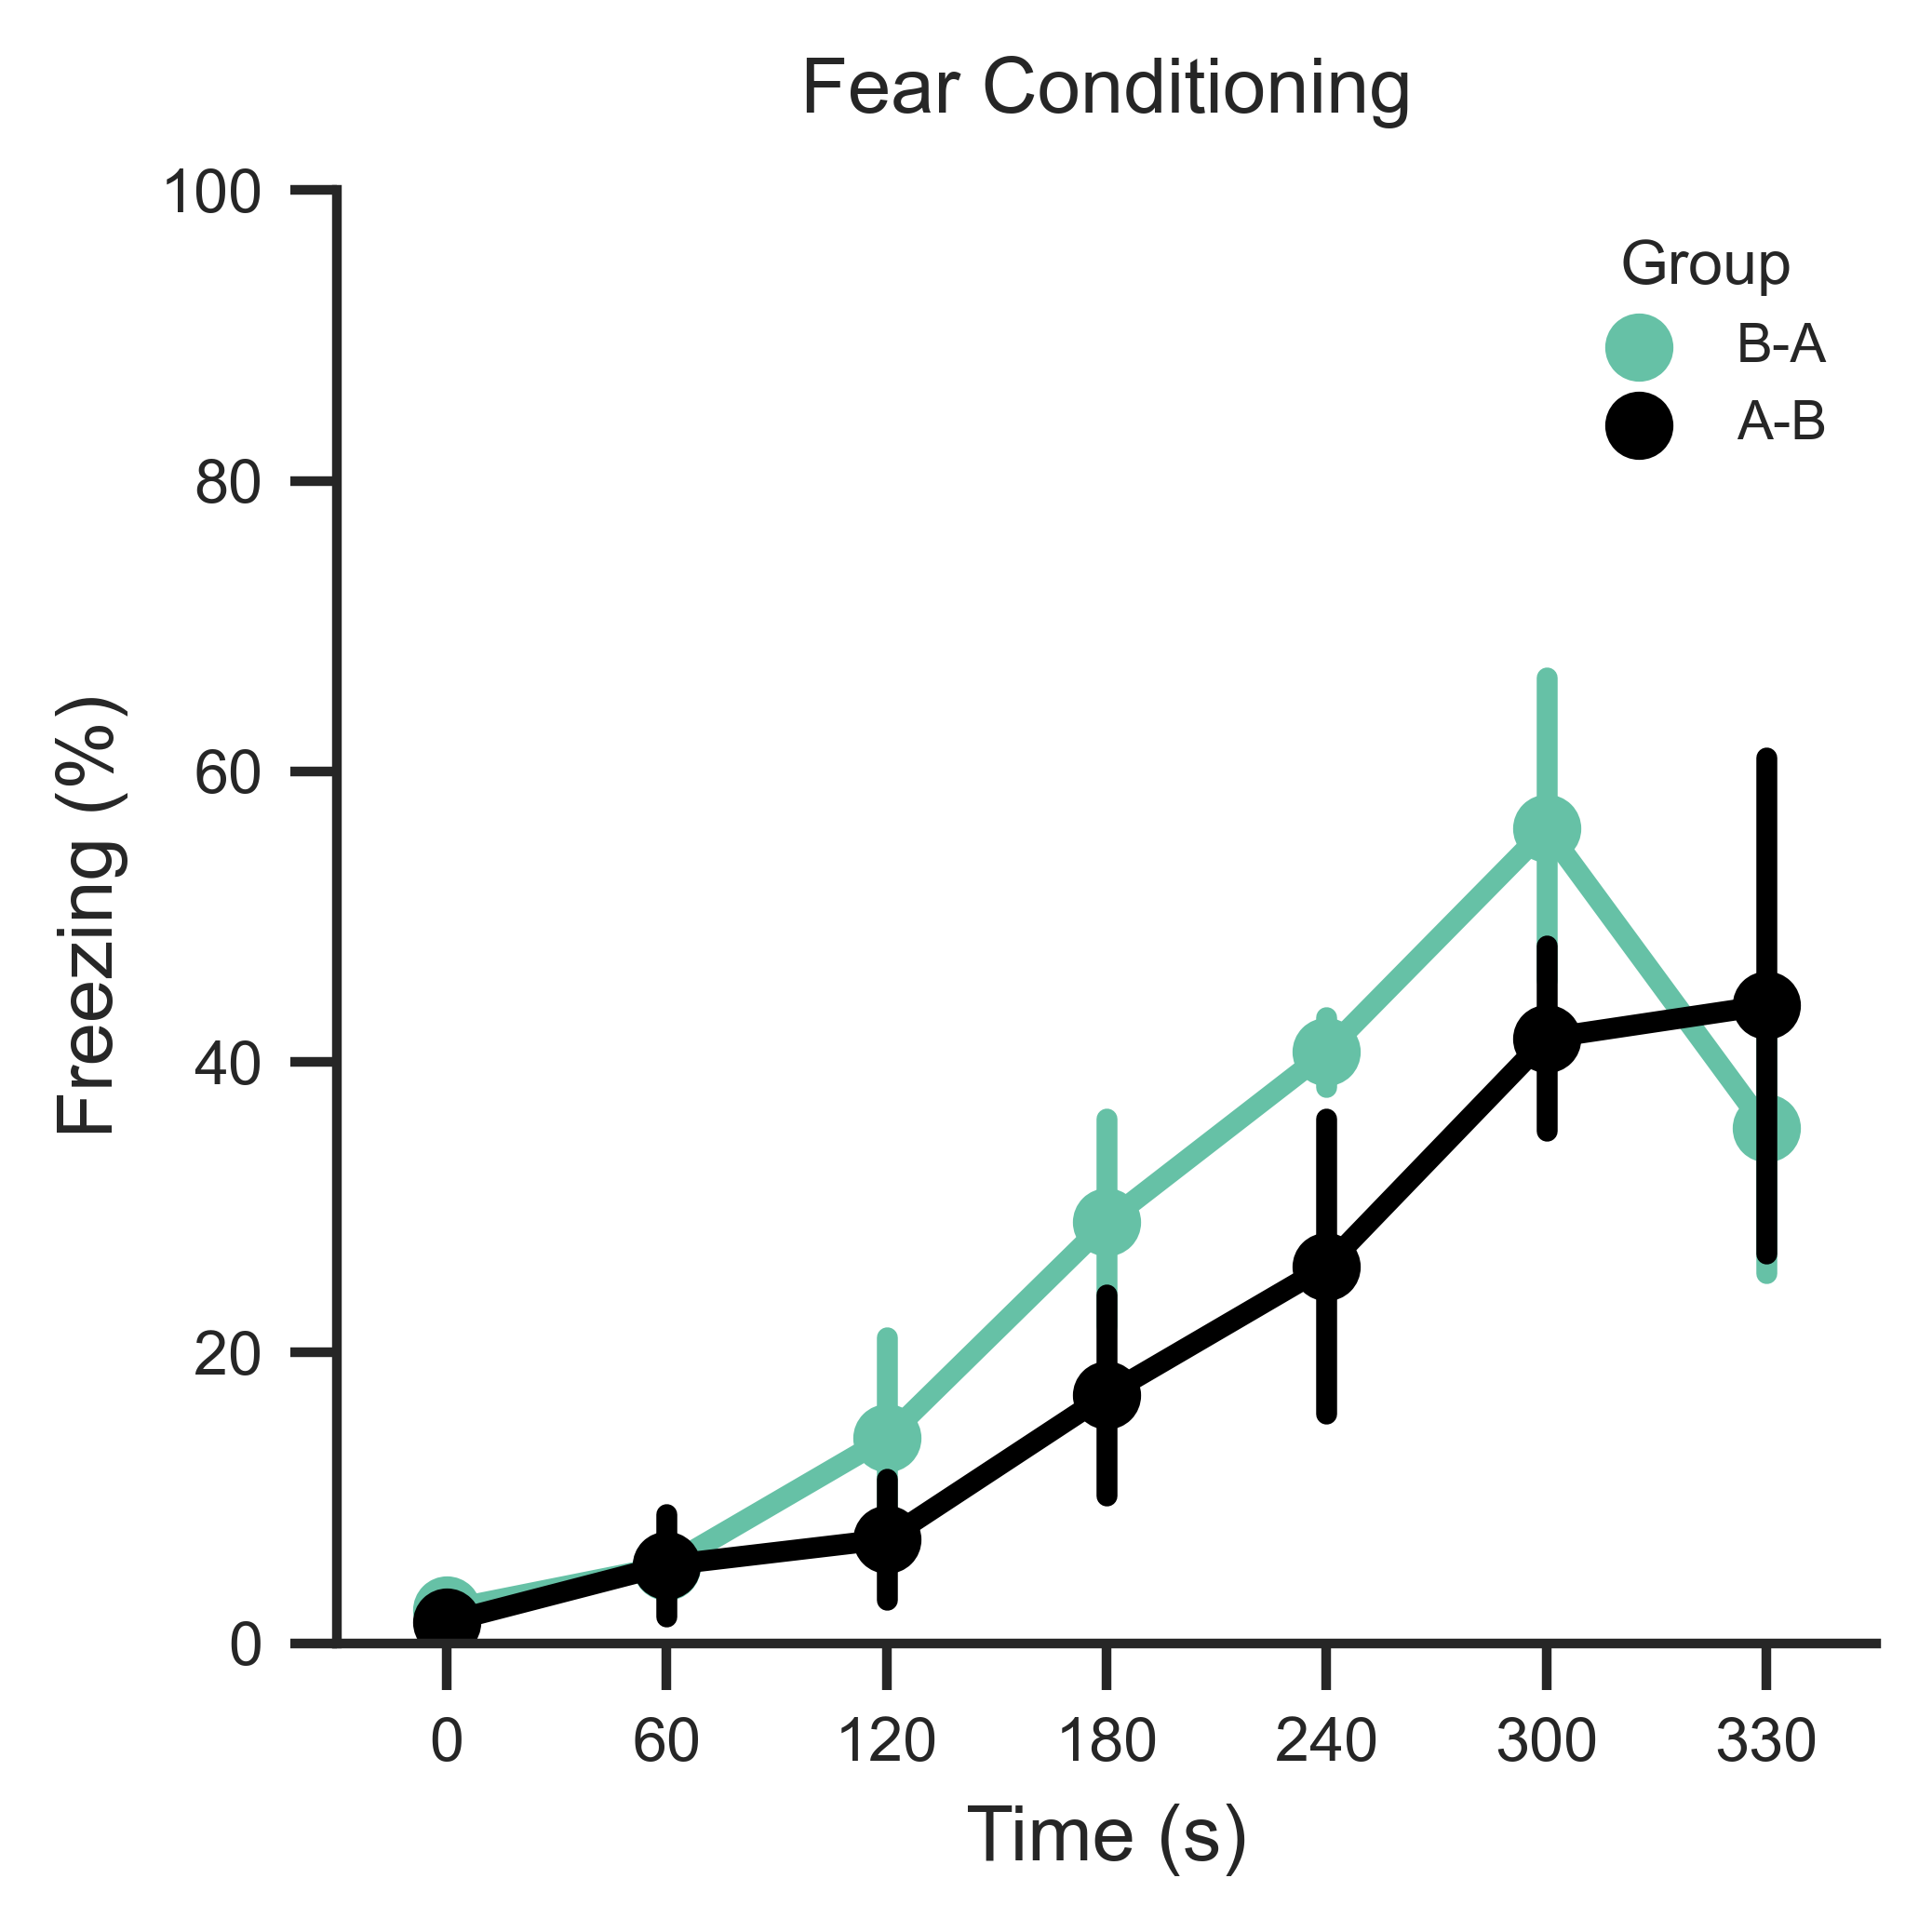

(<Figure size 2100x2100 with 1 Axes>,
 <Axes: title={'center': 'Fear Conditioning'}, xlabel='Time (s)', ylabel='Freezing (%)'>)

In [21]:
plot_freezing_across_time(df_fc, title='Fear Conditioning', save_path=r'/Users/suthardr/Desktop/fc_freezing_time_bygroup_clean.svg')

/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_85481/3312853139.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.barplot(


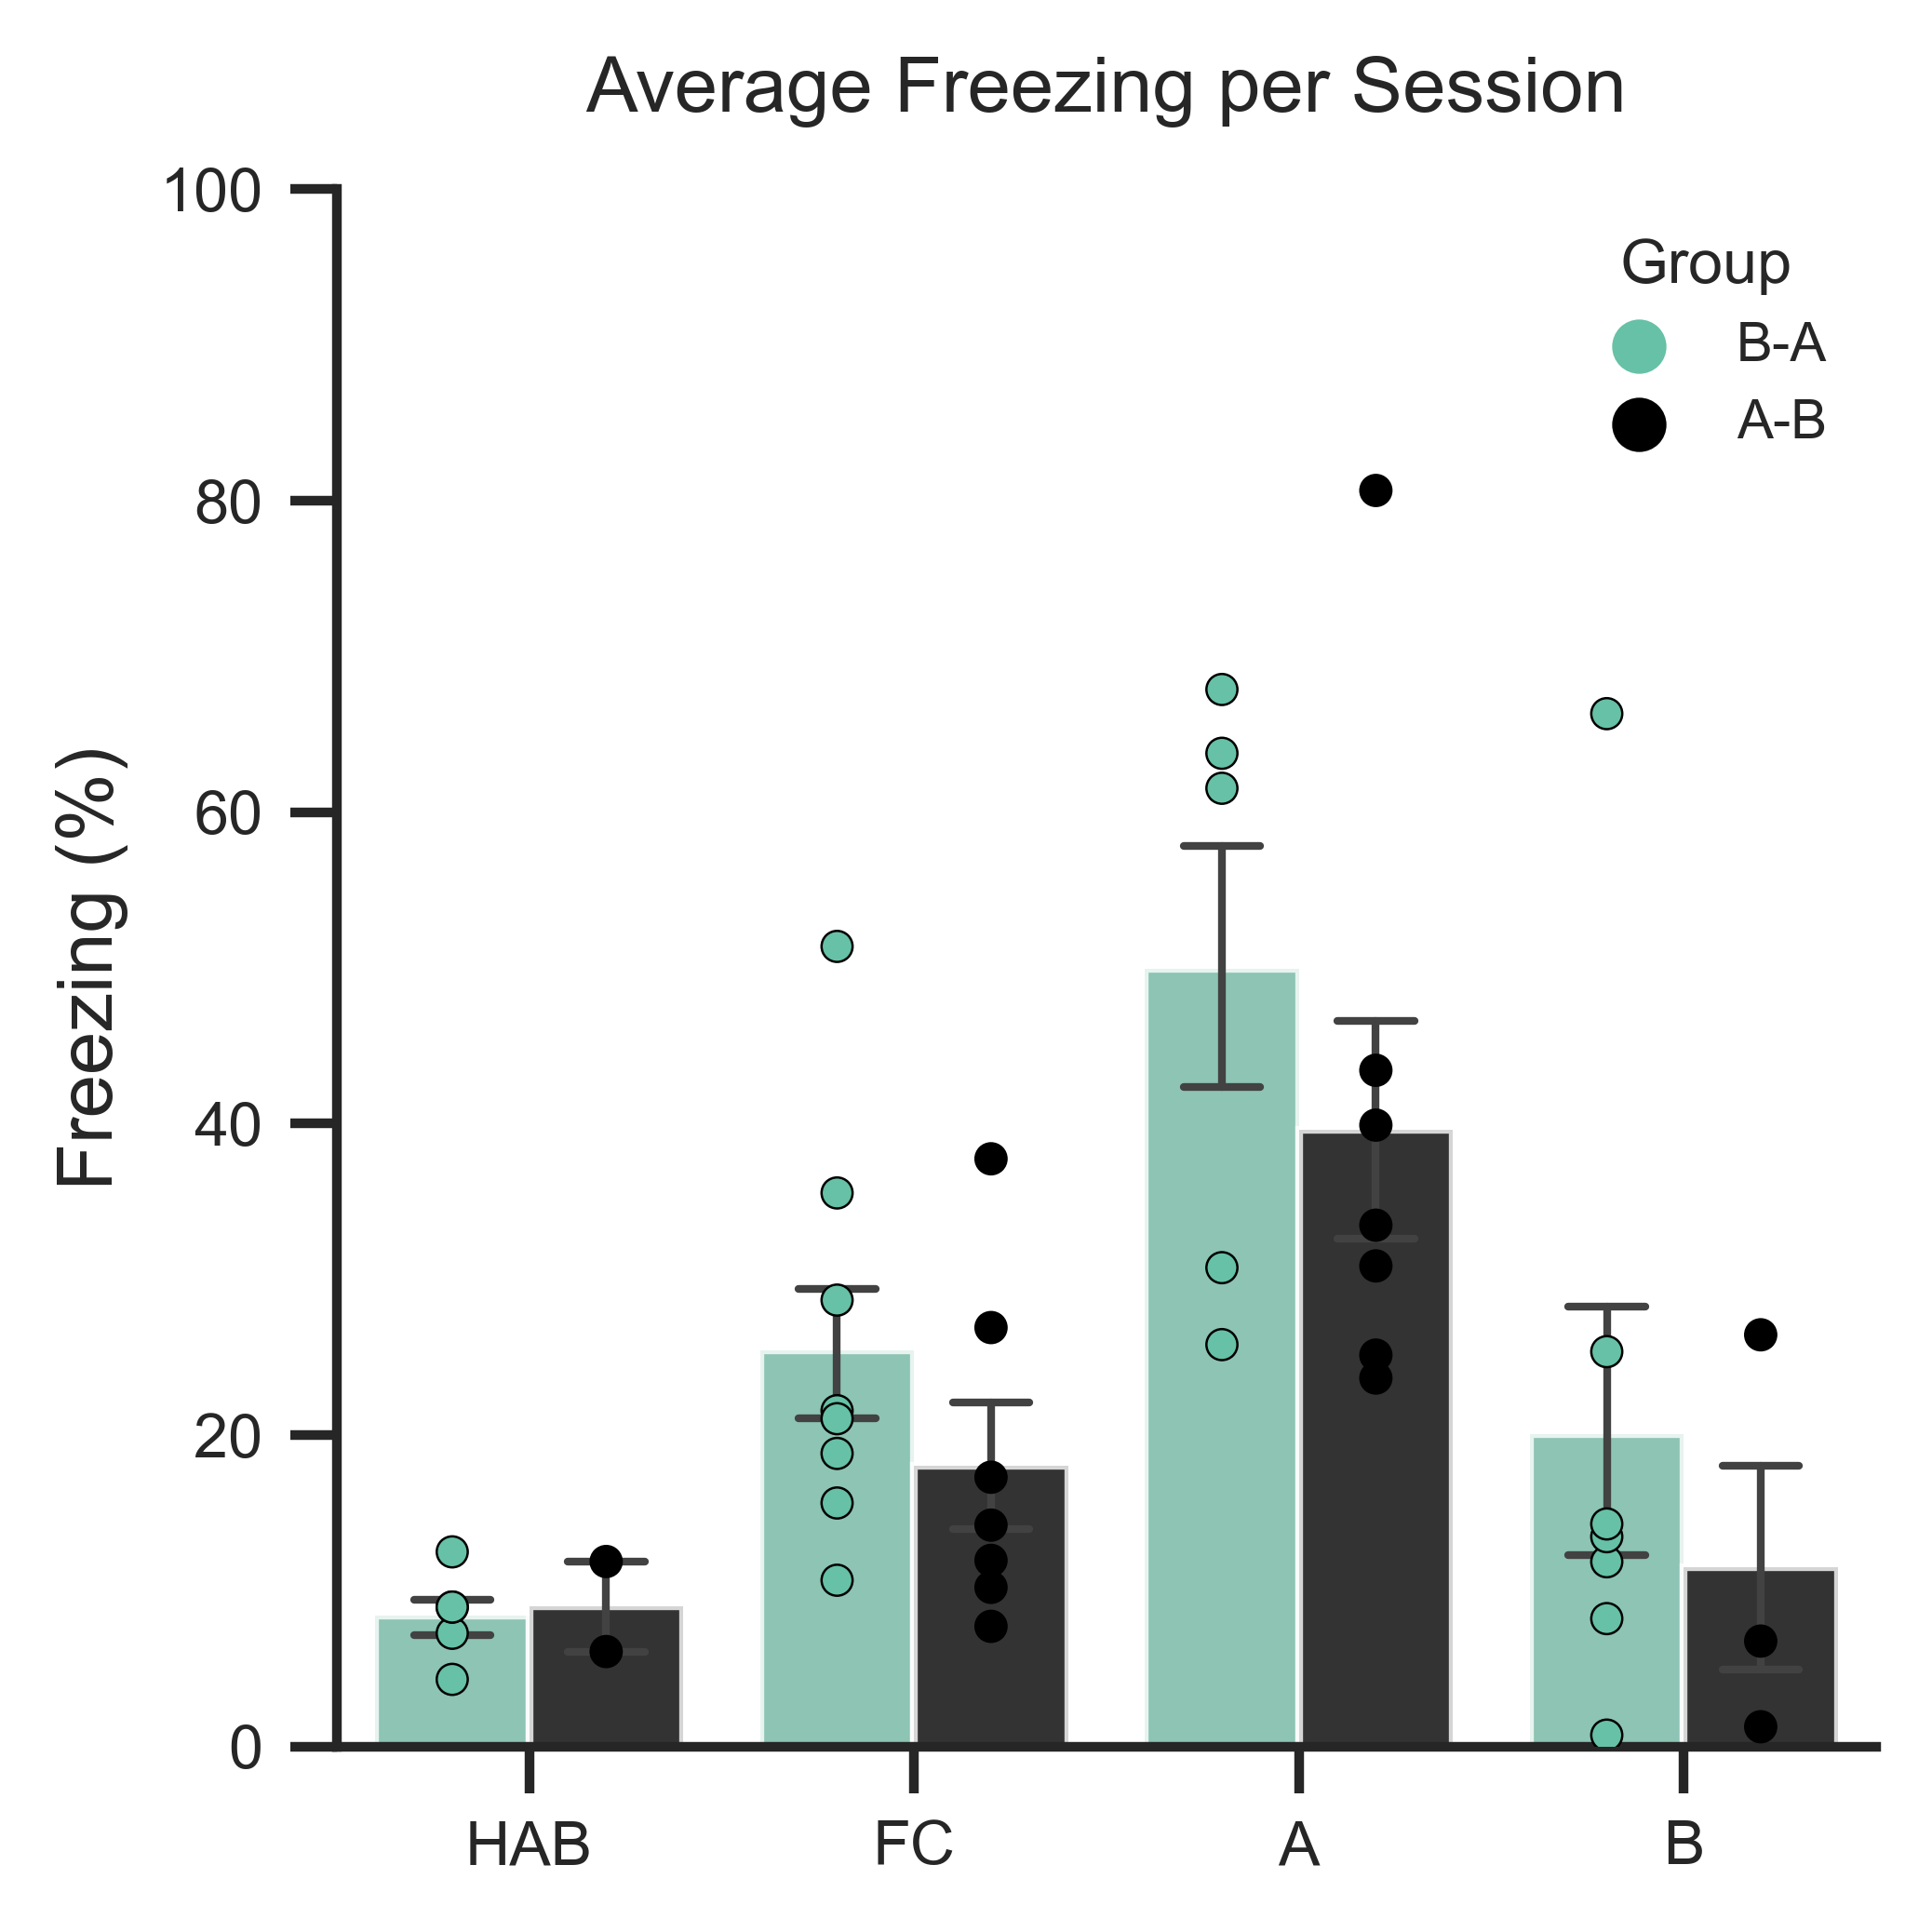

(<Figure size 2100x2100 with 1 Axes>,
 <Axes: title={'center': 'Average Freezing per Session'}, ylabel='Freezing (%)'>)

In [22]:
plot_avg_freezing(df_avg_all, title="Average Freezing per Session", save_path=r'/Users/suthardr/Desktop/allsessions_freezing_bygroup.svg')

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt


# Custom pastel color palette (4 colors)
session_colors = {
    'HAB': '#FC9D9A',     # Soft Coral
    'FC': '#B39BC8',      # Dusty Lavender
    'A':   '#8CCFD0',     # Cool Sky Blue
    'B':   '#A8D5BA'      # Warm Taupe
}

order = ['HAB', 'FC', "A", "B"]

def plot_avg_freezing_all(df, title="", save_path=None):
    sns.set(style="ticks", font="Arial")
    plt.rcParams.update({'font.size': 8})

    fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=600)

    # Create a list of bar colors in the desired session order
    bar_colors = [session_colors[session] for session in order]

    # Barplot — assign color list manually using palette override
    sns.barplot(
        x='Session', y='freezing_percentage', data=df,
        order=order, ci=68, capsize=.2, errwidth=1,
        alpha=0.8, ax=ax, palette=bar_colors
    )

    # Stripplot — black dots on top of each bar
    sns.stripplot(
        x='Session', y='freezing_percentage', data=df,
        jitter=True, linewidth=0.3, edgecolor='black',
        size=4, order=order, ax=ax,palette=session_colors
    )


    ax.legend_.remove() if ax.legend_ else None
    ax.set_ylabel('Freezing (%)', fontsize=10)
    ax.set_xlabel('', fontsize=10)
    ax.tick_params(labelsize=8)
    ax.set_ylim(0, 100)
    ax.set_title(title, fontsize=10, pad=10)
    sns.despine()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight', format='svg')
    plt.show()
    return fig, ax

def plot_freezing_across_time_all(df, title="", save_path=None):
    sns.set(style="ticks", font="Arial")
    plt.rcParams.update({'font.size': 8})

    fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=600)
    sns.set_palette(sns.color_palette(colors))

    # Pointplot without hue
    sns.pointplot(x='bin', y='freezing_percentage', data=df,
                  errorbar='se', ax=ax, color=colors[0])

    # Optional: stripplot without hue
    sns.stripplot(x='bin', y='freezing_percentage', data=df,
                  jitter=True, size=4, linewidth=0.3, edgecolor='black',
                  ax=ax, color='#66C1A6')

    ax.set_ylabel("Freezing (%)", fontsize=10)
    ax.set_xlabel("Time (s)", fontsize=10)
    ax.tick_params(labelsize=8)
    ax.set_ylim(0, 100)
    ax.set_title(title, fontsize=10, pad=10)

    # Replace x labels with your desired time points
    custom_labels = [0, 60, 120, 180, 240, 300, 330]
    ax.set_xticks(range(len(custom_labels)))
    ax.set_xticklabels(custom_labels)

    # Remove legend (no Group)
    ax.legend_.remove() if ax.legend_ else None

    sns.despine()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight', format='svg')
    plt.show()
    return fig, ax


ModuleNotFoundError: No module named 'statannotations'

/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_72307/2890687334.py:24: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.barplot(
/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_72307/2890687334.py:31: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


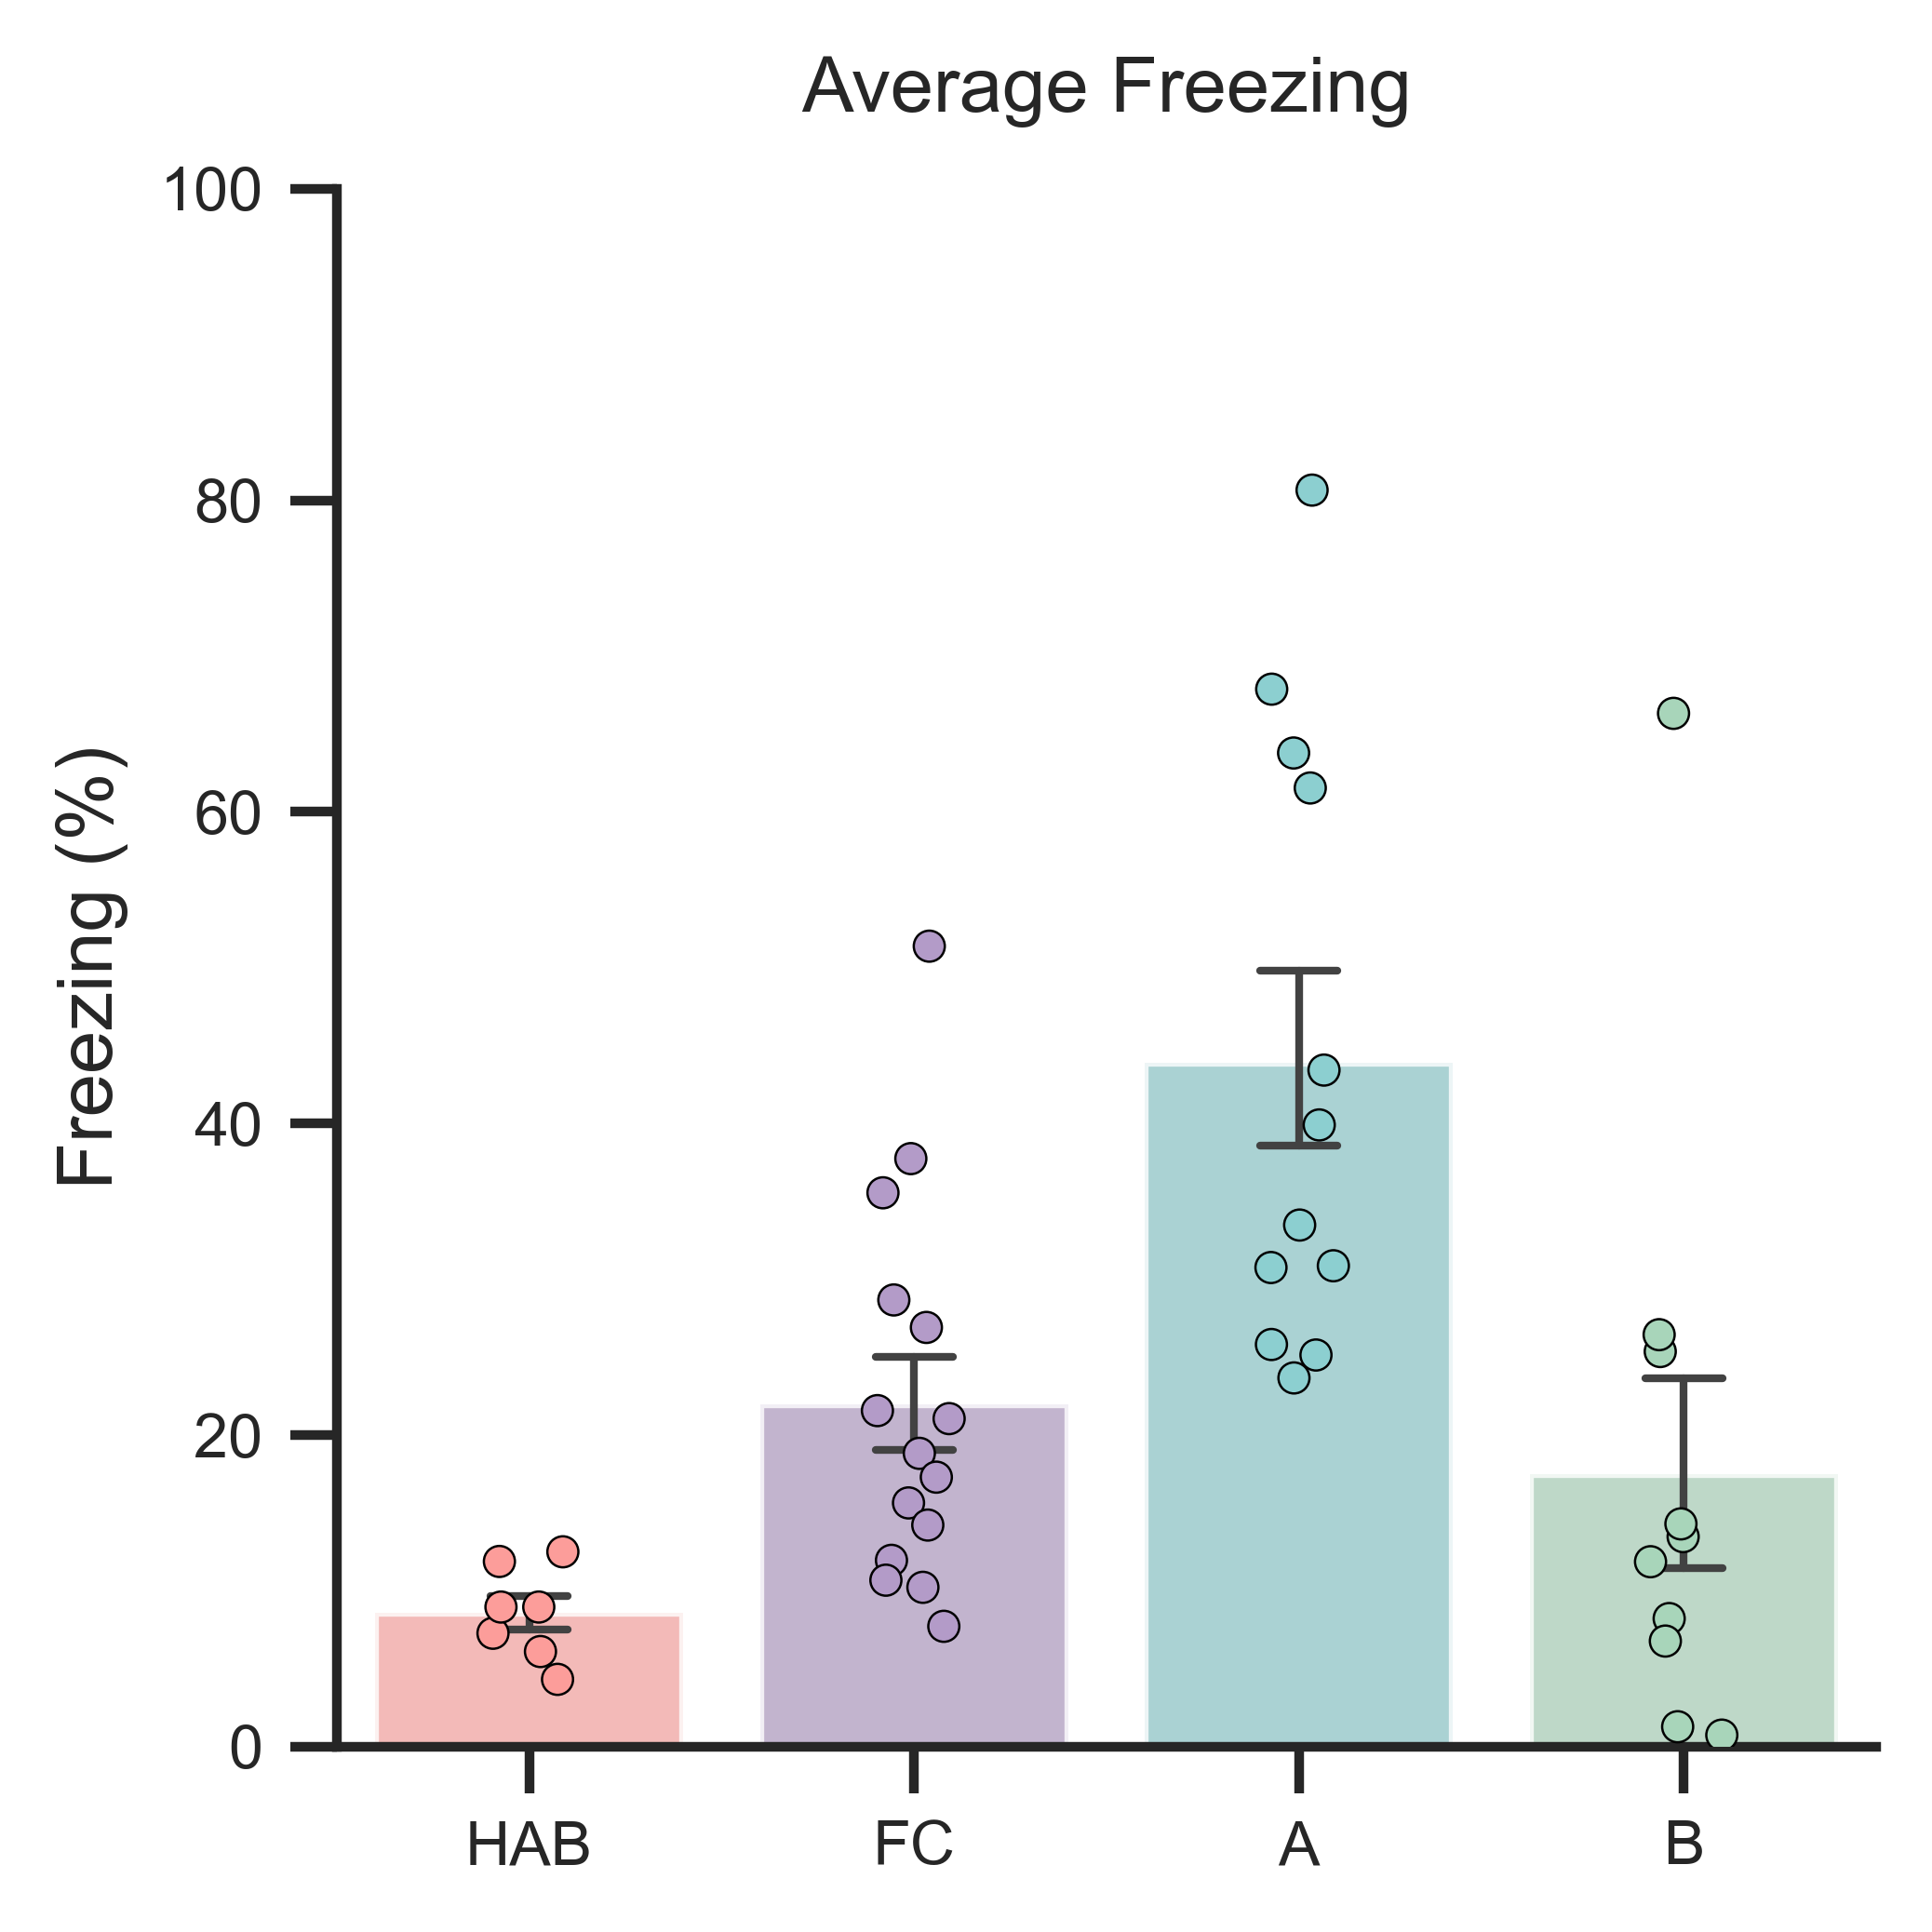

(<Figure size 2100x2100 with 1 Axes>,
 <Axes: title={'center': 'Average Freezing'}, ylabel='Freezing (%)'>)

In [18]:
plot_avg_freezing_all(df_avg_all, title="Average Freezing",
save_path=r'/Users/suthardr/Desktop/allsessions_freezing_concat_jitter.svg')

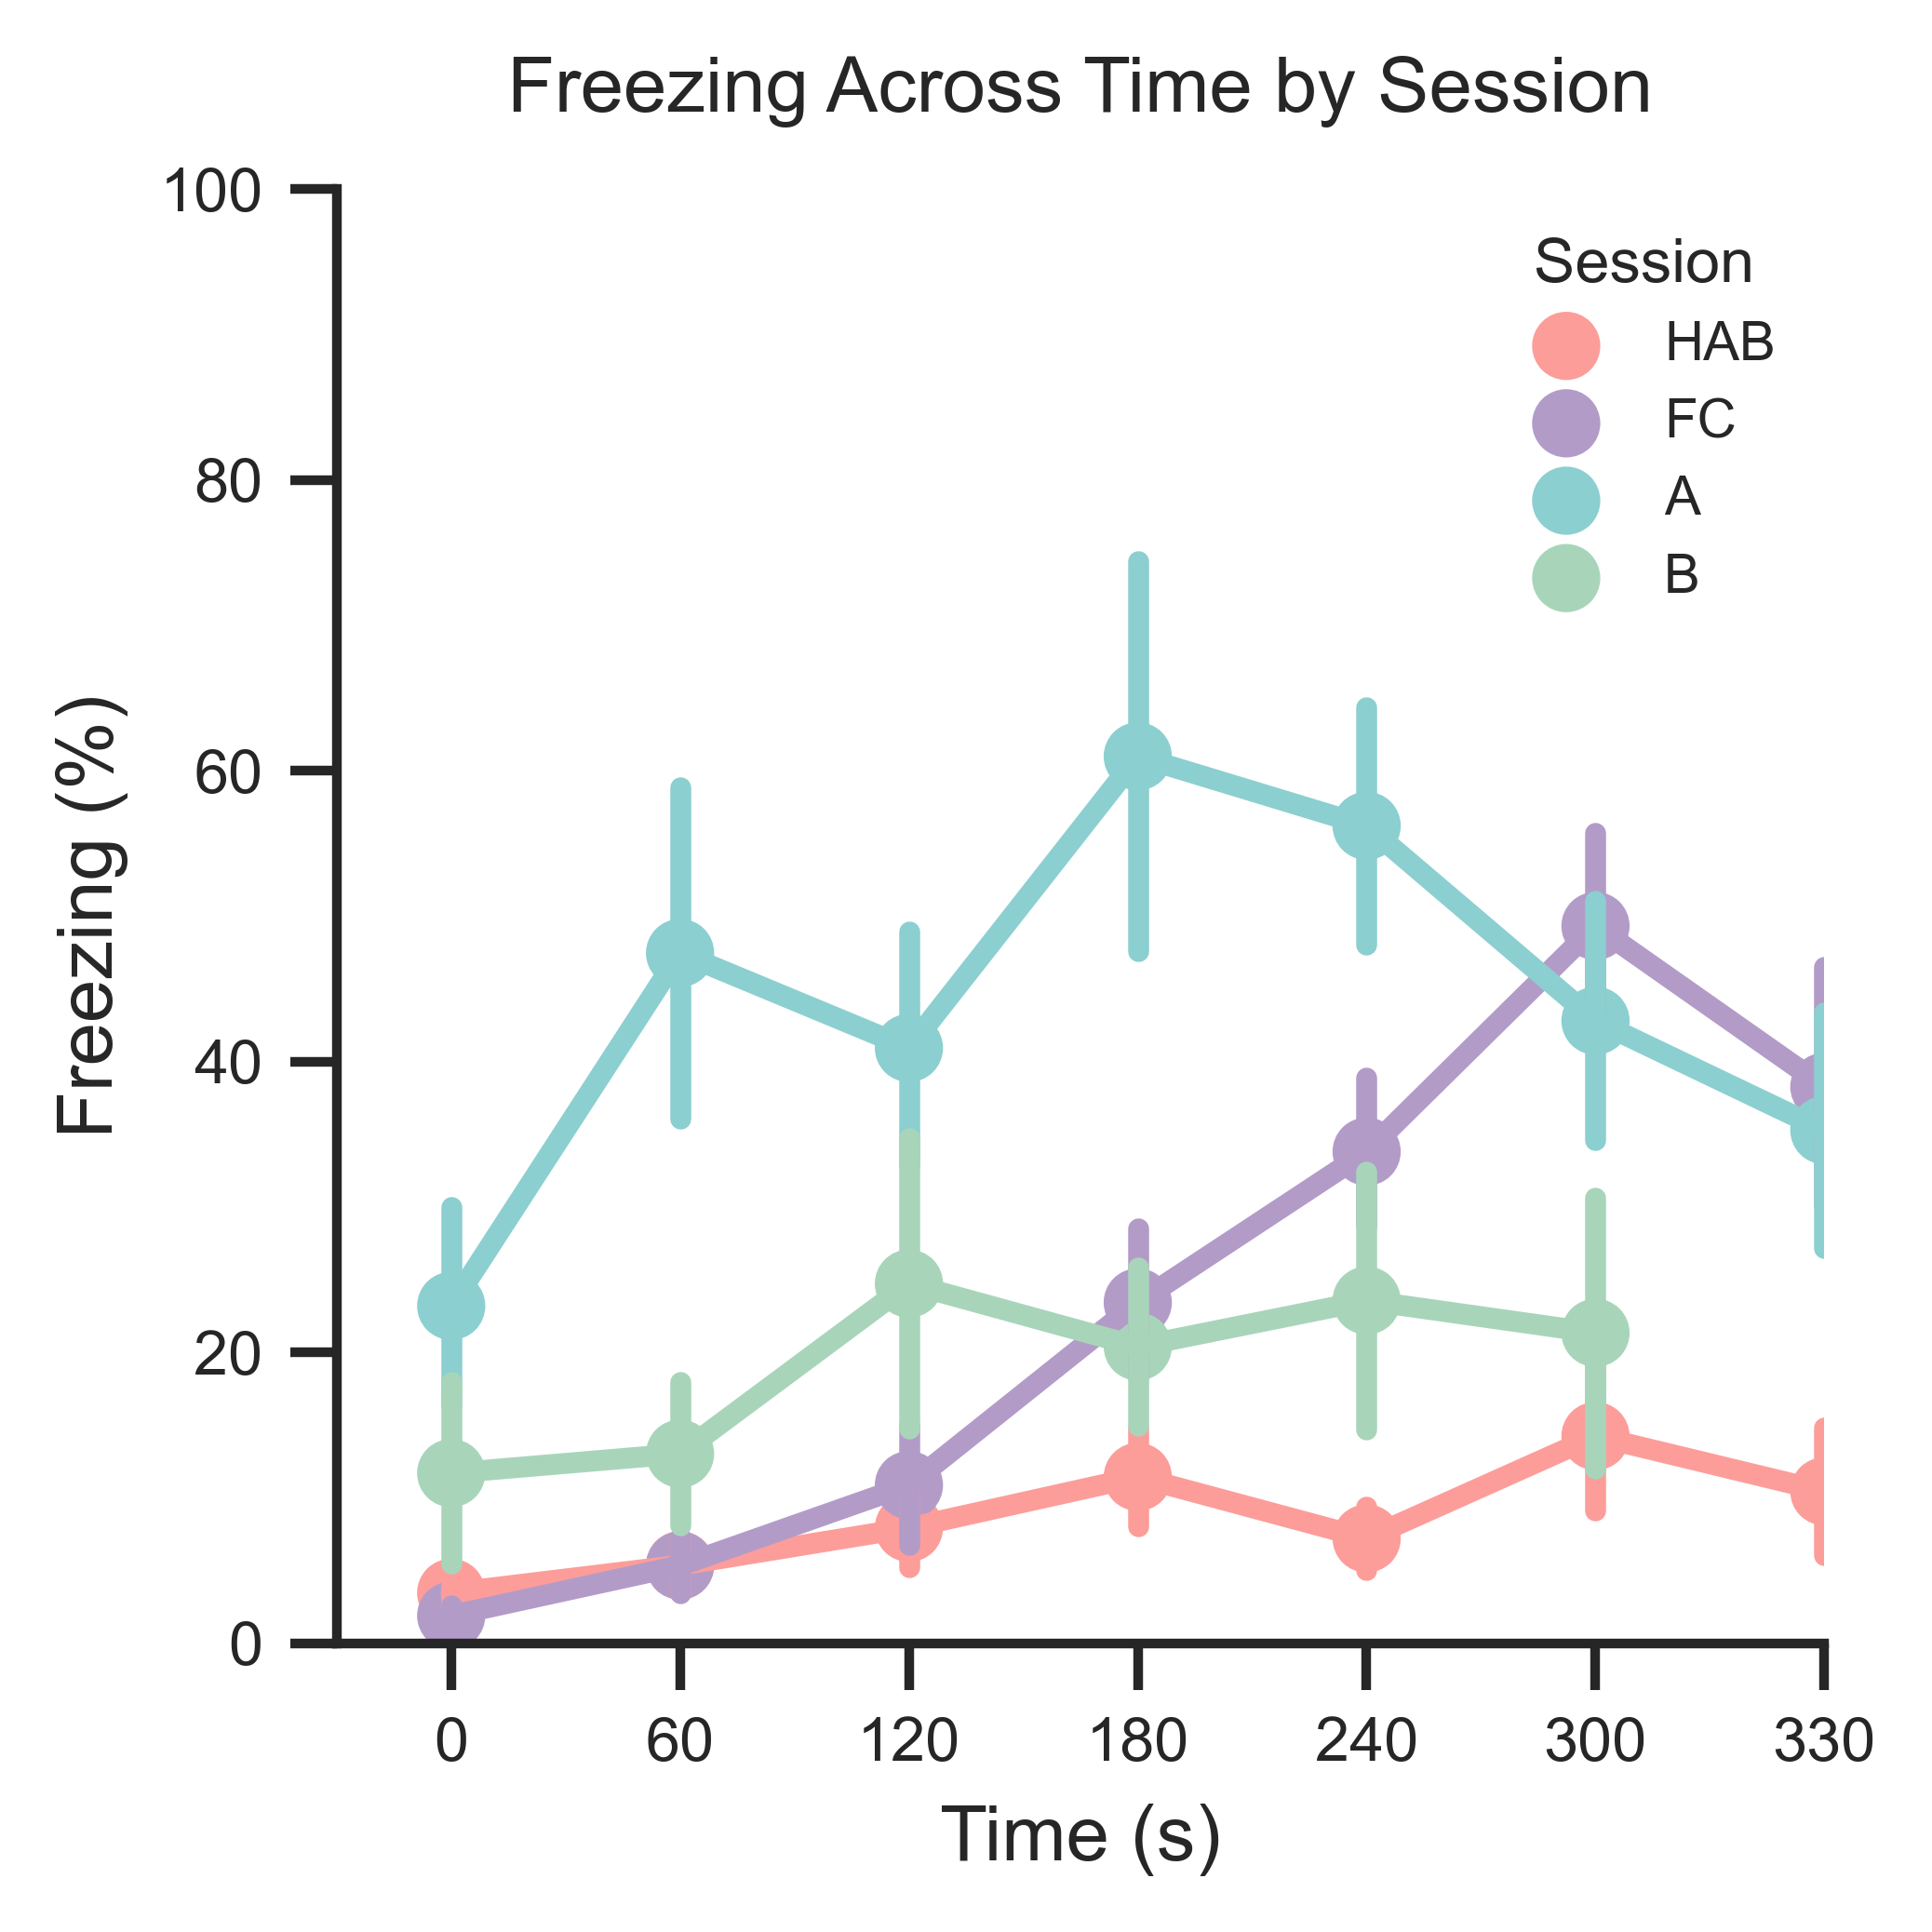

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Add a 'Session' column to each dataframe
df_hab['Session'] = 'HAB'
df_fc['Session'] = 'FC'
df_A['Session'] = 'A'
df_B['Session'] = 'B'

# Combine into one DataFrame
df_all_sessions = pd.concat([df_hab, df_fc, df_A, df_B], ignore_index=True)

# Custom hex colors per session (you can adjust as needed)
session_colors = {
    'HAB': '#FC9D9A',     # Soft Coral
    'FC': '#B39BC8',      # Dusty Lavender
    'A':   '#8CCFD0',     # Cool Sky Blue
    'B':   '#A8D5BA'
}

# Set aesthetics
sns.set(style="ticks", font="Arial")
plt.rcParams.update({'font.size': 8})

fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=600)

# Plot each session's data
for session in ['HAB', 'FC', 'A', 'B']:
    session_df = df_all_sessions[df_all_sessions['Session'] == session]
    sns.pointplot(
        x='bin', y='freezing_percentage', data=session_df,
        errorbar='se', label=session, ax=ax, color=session_colors[session]
    )

# Customize plot
ax.set_ylabel("Freezing (%)", fontsize=10)
ax.set_xlabel("Time (s)", fontsize=10)
ax.tick_params(labelsize=8)
ax.set_ylim(0, 100)
ax.set_title("Freezing Across Time by Session", fontsize=10, pad=10)

# Replace bin labels with time (adjust if needed)
custom_labels = [0, 60, 120, 180, 240, 300, 330]
ax.set_xticks(range(len(custom_labels)))
ax.set_xticklabels(custom_labels)

# Legend
ax.legend(title="Session", fontsize=7, title_fontsize=8, frameon=False, loc='upper right')

sns.despine()
plt.tight_layout()

# Optional: save
plt.savefig(r'/Users/suthardr/Desktop/allsessions_freezing_concat_acrosstime.svg', format='svg', bbox_inches='tight')

plt.show()

In [23]:
df_avg_all = df_avg_all.reset_index(drop=True)


In [24]:
df_avg_all

,Mouse,Session,Group,Sex,freezing_percentage
0,astroF10,FC,B-A,astroF10,51.382857
1,astroF3,FC,B-A,astroF3,18.827143
2,astroF5,FC,B-A,astroF5,21.570238
3,astroF6,FC,A-B,astroF6,17.299048
4,astroF7,FC,A-B,astroF7,10.227381
5,astroF8,FC,B-A,astroF8,28.673333
6,astroF9,FC,B-A,astroF9,35.551905
7,astroM10,FC,A-B,astroM10,37.745238
8,astroM3,FC,A-B,astroM3,26.909167
9,astroM4,FC,A-B,astroM4,7.724722


In [27]:
import statsmodels.formula.api as smf
#Missing data from some mice so went with mixedlm
# Your dataframe: df with columns 'freezing_percentage', 'Group', 'Session', 'Mouse'
df = df_avg_all
# Convert categorical variables to categorical dtype (if not already)
df['Group'] = df['Group'].astype('category')
df['Session'] = df['Session'].astype('category')
df['Mouse'] = df['Mouse'].astype('category')
df['Sex'] = df['Sex'].astype('category')

df['Session'] = pd.Categorical(df['Session'], categories=['HAB', 'A', 'B', 'FC'], ordered=False)

# Fit a mixed-effects model with random intercepts for Mouse
model = smf.mixedlm("freezing_percentage ~ Session", data=df, groups=df["Mouse"])

result = model.fit()
print(result.summary())

#Session[T.A] = +37.6% → mice freeze ~38% more in A vs HAB (p < 0.001).
#Session[T.B] = +10.6% → B vs HAB is not significant (p = 0.14).
#Session[T.FC] = +16.1% → FC vs HAB is significant (p = 0.022).
#So HAB < A, and HAB < FC, but HAB vs B is not different

              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: freezing_percentage
No. Observations: 44      Method:             REML               
No. Groups:       15      Scale:              200.9112           
Min. group size:  1       Log-Likelihood:     -170.6360          
Max. group size:  4       Converged:          Yes                
Mean group size:  2.9                                            
-------------------------------------------------------------------
                Coef.    Std.Err.     z     P>|z|   [0.025   0.975]
-------------------------------------------------------------------
Intercept        5.867      6.224   0.943   0.346   -6.331   18.066
Session[T.A]    37.595      7.119   5.281   0.000   23.642   51.548
Session[T.B]    10.644      7.210   1.476   0.140   -3.488   24.776
Session[T.FC]   16.098      7.032   2.289   0.022    2.316   29.880
Group Var       40.219      3.581                                  



In [26]:
import pingouin as pg
posthoc_between = pg.pairwise_ttests(
    dv='freezing_percentage',
    between='Session',   # UNPAIRED
    data=df,
    padjust='bonf',
    effsize='hedges'
)
print(posthoc_between[['A','B','T','p-unc','p-corr','hedges']])

     A   B         T     p-unc    p-corr    hedges
0  HAB   A -6.152751  0.000052  0.000312 -2.137026
1  HAB   B -1.440111  0.181628  1.000000 -0.562968
2  HAB  FC -4.018460  0.000878  0.005268 -1.250810
3    A   B  3.188238  0.004750  0.028503  1.311471
4    A  FC  3.403113  0.003260  0.019561  1.345063
5    B  FC -0.655329  0.523028  1.000000 -0.283117


/Users/suthardr/opt/anaconda3/envs/dCA1_Paper/lib/python3.10/site-packages/pingouin/pairwise.py:28: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)


/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_37317/2047086362.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.barplot(
/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_37317/2047086362.py:15: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(


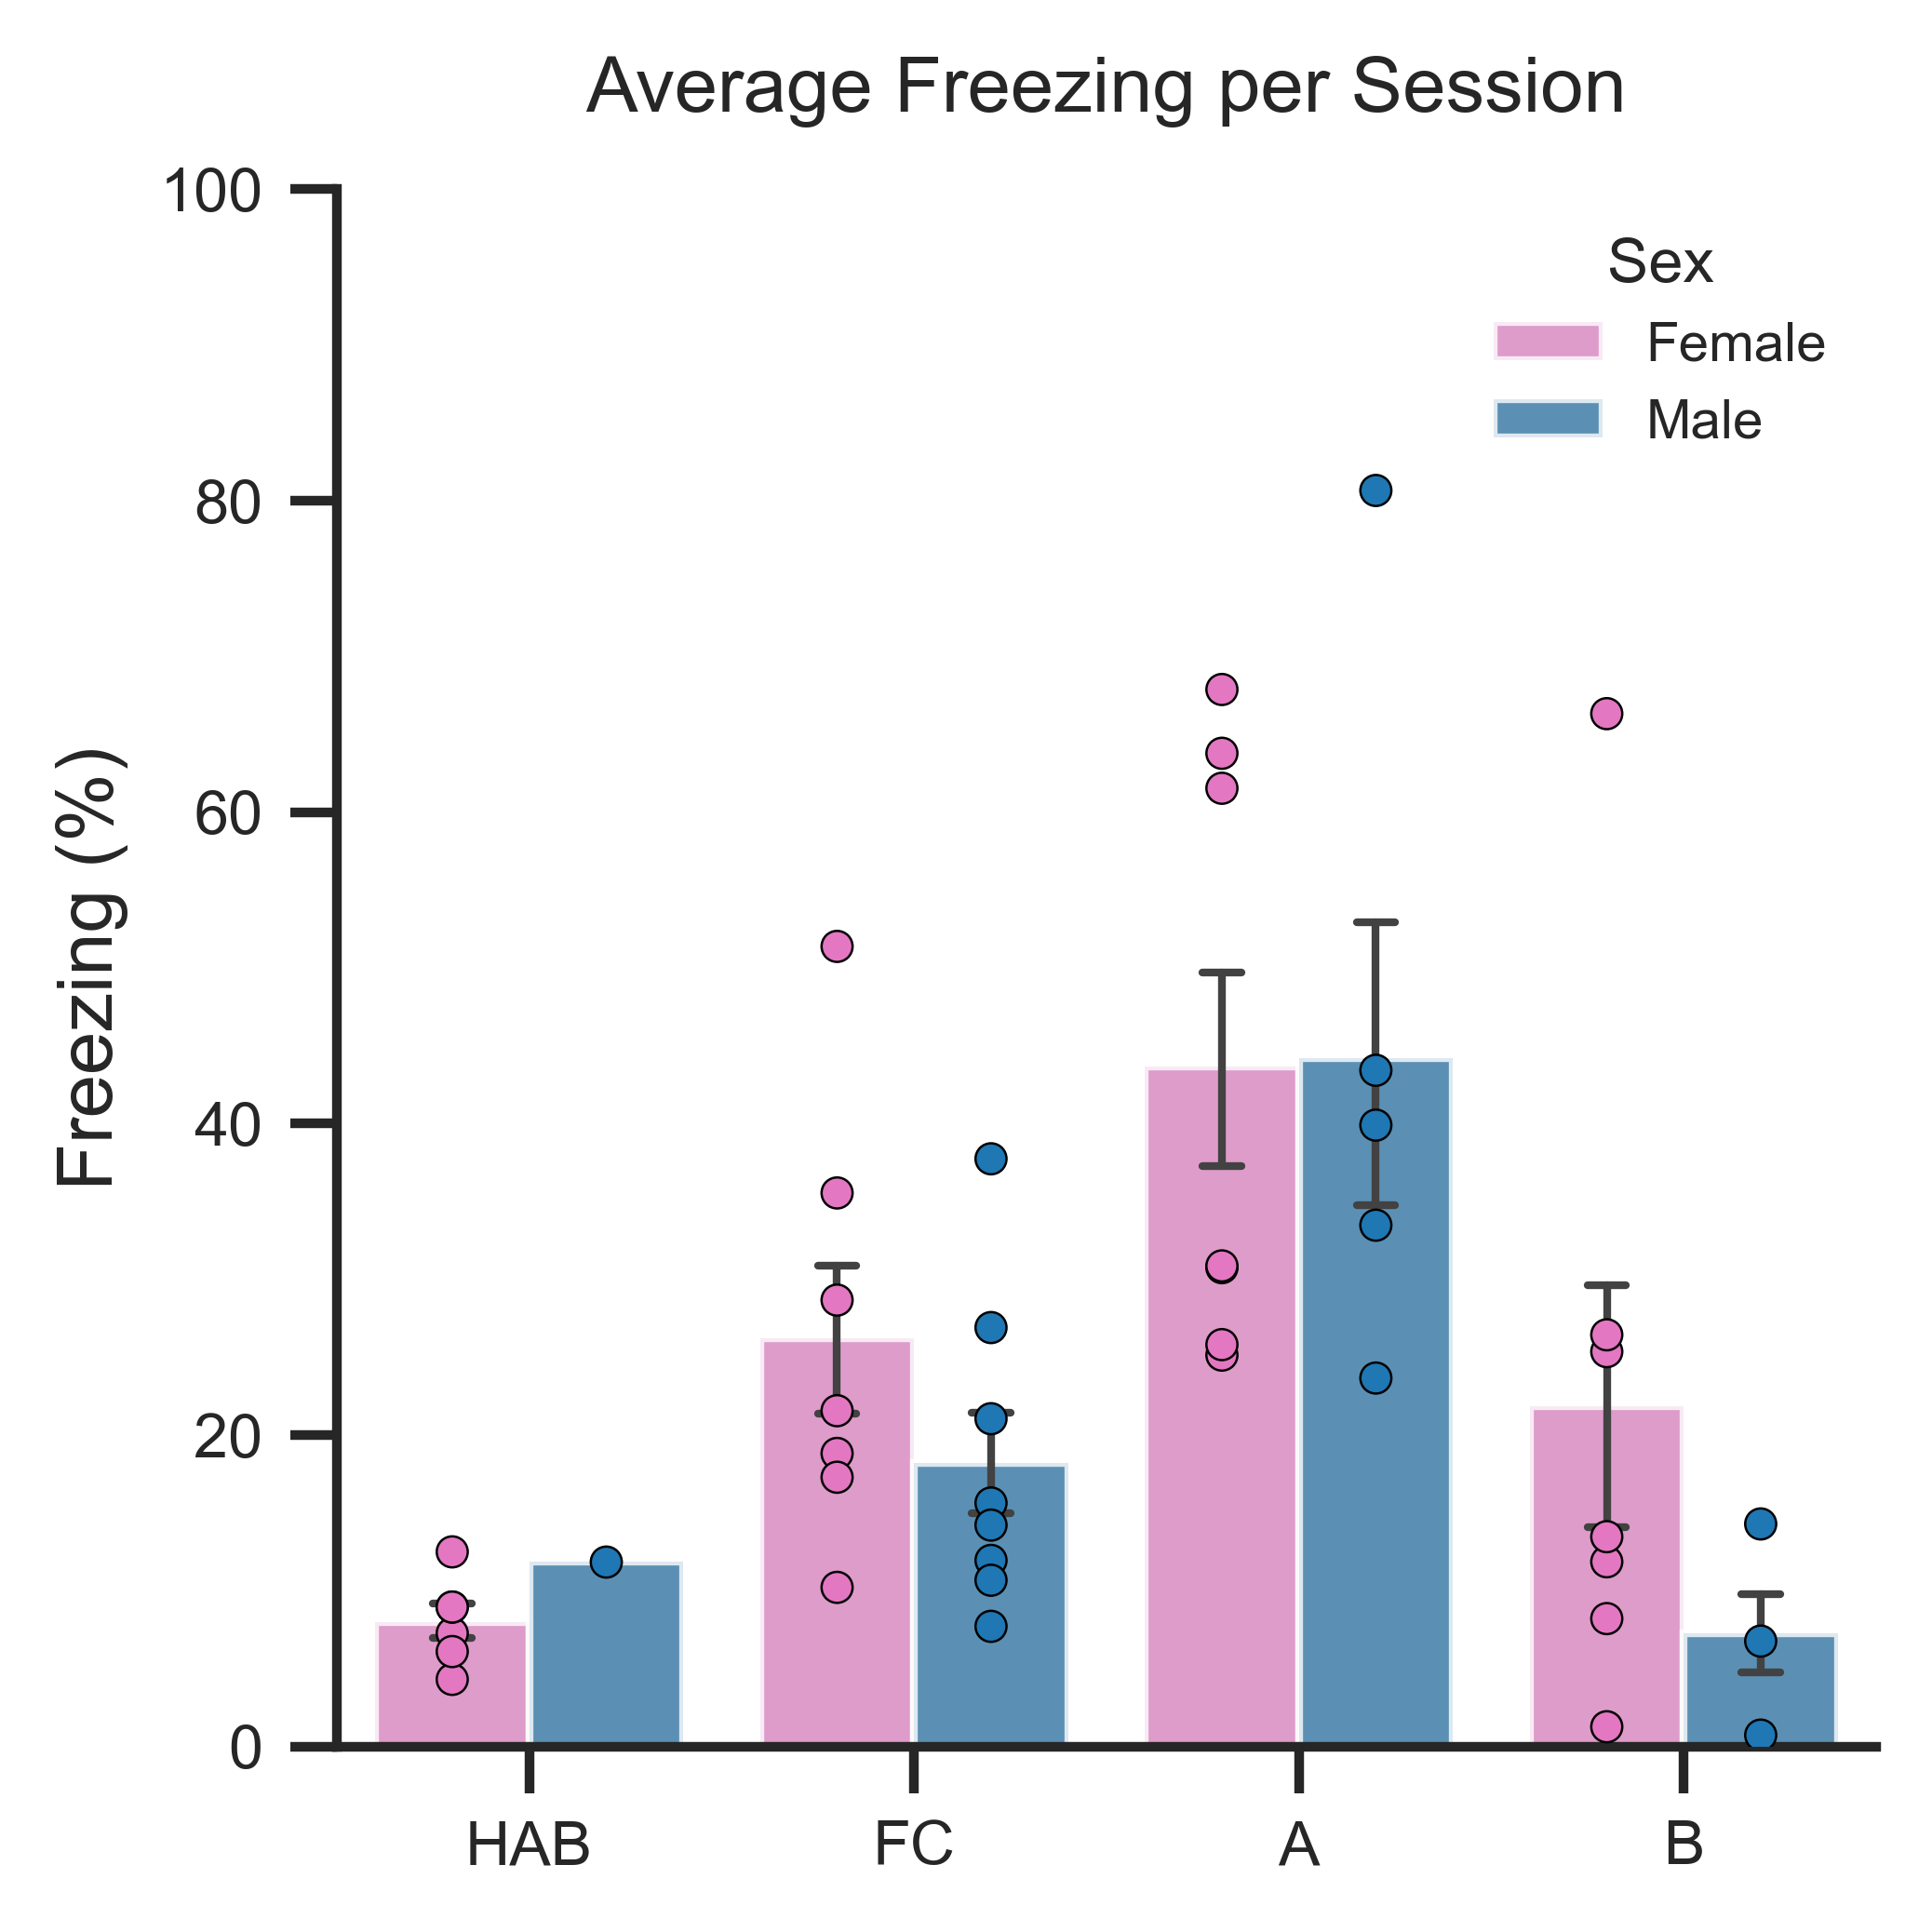

(<Figure size 2100x2100 with 1 Axes>,
 <Axes: title={'center': 'Average Freezing per Session'}, ylabel='Freezing (%)'>)

In [15]:
#Plot by sex
import matplotlib.pyplot as plt

def plot_avg_freezing(df, title="", save_path=None):
    import seaborn as sns
    import matplotlib.pyplot as plt

    sns.set(style="ticks", font="Arial")
    colors = ["#e377c2", "#1f77b4"]
    plt.rcParams.update({'font.size': 8, 'svg.fonttype': 'none' })

    fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=600)
    sns.set_palette(sns.color_palette(colors))

    sns.barplot(
        x='Session', y='freezing_percentage', hue='Sex', data=df,
        order=['HAB', 'FC', "A", "B"],
        ci=68, capsize=.2, errwidth=1, alpha=0.8, ax=ax
    )

    sns.stripplot(
        x='Session', y='freezing_percentage', hue='Sex', data=df,
        dodge=True, jitter=False, linewidth=0.3, edgecolor='black', size=4,
        order=['HAB', 'FC', "A", "B"], ax=ax
    )

    # Clean legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title='Sex', loc='upper right',
              fontsize=7, title_fontsize=8, frameon=False)

    ax.set_ylabel('Freezing (%)', fontsize=10)
    ax.set_xlabel('', fontsize=10)
    ax.tick_params(labelsize=8)
    ax.set_ylim(0, 100)
    ax.set_title(title, fontsize=10, pad=10)
    sns.despine()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight', format='svg')
    plt.show()
    return fig, ax


def plot_freezing_across_time(df, title="", save_path=None):
    import seaborn as sns
    import matplotlib.pyplot as plt

    sns.set(style="ticks", font="Arial")
    colors = ["#e377c2", "#1f77b4"]
    plt.rcParams.update({'font.size': 8})

    fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=600)
    sns.set_palette(sns.color_palette(colors))

    sns.pointplot(x='bin', y='freezing_percentage', hue='Sex', data=df,
                  errorbar='se', ax=ax)

    # sns.stripplot(x='bin', y='freezing_percentage', hue='Sex', data=df,
    #               jitter=False, size=4, linewidth=0.3, edgecolor='black',
    #               dodge=True, ax=ax)

    ax.set_ylabel("Freezing (%)", fontsize=10)
    ax.set_xlabel("Time (s)", fontsize=10)
    ax.tick_params(labelsize=8)
    ax.set_ylim(0, 100)
    ax.set_title(title, fontsize=10, pad=10)

    # Optional: Replace x labels with time in seconds
    custom_labels = [0, 60, 120, 180, 240, 300, 330]
    ax.set_xticks(range(len(custom_labels)))
    ax.set_xticklabels(custom_labels)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title='Sex', loc='upper right',
              fontsize=7, title_fontsize=8, frameon=False)

    sns.despine()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight', format='svg')
    plt.show()
    return fig, ax


# plot_freezing_across_time(df_fc, title='Fear Conditioning',
#                           save_path=r'/Users/suthardr/Desktop/fc_freezing_time_bysex_clean.svg')
plot_avg_freezing(df_avg_all, title="Average Freezing per Session",
                  save_path=r'/Users/suthardr/Desktop/allsessions_freezing_bysex.svg')

In [30]:
import statsmodels.formula.api as smf
#Missing data from some mice so went with mixedlm
# Your dataframe: df with columns 'freezing_percentage', 'Group', 'Session', 'Mouse'
df = df_avg_all
# Convert categorical variables to categorical dtype (if not already)
df['Group'] = df['Group'].astype('category')
df['Session'] = df['Session'].astype('category')
df['Mouse'] = df['Mouse'].astype('category')
df['Sex'] = df['Sex'].astype('category')

df['Session'] = pd.Categorical(df['Session'], categories=['HAB', 'A', 'B', 'FC'], ordered=False)

# Fit a mixed-effects model with random intercepts for Mouse
model = smf.mixedlm("freezing_percentage ~ Sex", data=df, groups=df["Mouse"])


result = model.fit()
print(result.summary())

              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: freezing_percentage
No. Observations: 44      Method:             REML               
No. Groups:       15      Scale:              390.5969           
Min. group size:  1       Log-Likelihood:     -188.1118          
Max. group size:  4       Converged:          Yes                
Mean group size:  2.9                                            
-------------------------------------------------------------------
              Coef.    Std.Err.     z      P>|z|    [0.025   0.975]
-------------------------------------------------------------------
Intercept     25.563      3.864    6.616   0.000    17.989   33.136
Sex[T.Male]   -2.024      6.244   -0.324   0.746   -14.262   10.214
Group Var      2.738      4.280                                    



/Users/suthardr/opt/anaconda3/envs/dCA1_Paper/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/suthardr/opt/anaconda3/envs/dCA1_Paper/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


In [34]:
import statsmodels.formula.api as smf

model = smf.mixedlm(
    "freezing_percentage ~ Sex + Group + Session",
    data=df,
    groups=df["Mouse"]
).fit()

print(model.summary())


              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: freezing_percentage
No. Observations: 44      Method:             REML               
No. Groups:       15      Scale:              197.0157           
Min. group size:  1       Log-Likelihood:     -164.0782          
Max. group size:  4       Converged:          Yes                
Mean group size:  2.9                                            
------------------------------------------------------------------
                  Coef.   Std.Err.    z     P>|z|   [0.025  0.975]
------------------------------------------------------------------
Intercept          3.255     7.626   0.427  0.669  -11.692  18.202
Sex[T.Male]       -4.654     6.342  -0.734  0.463  -17.084   7.776
Group[T.B-A]       5.688     6.197   0.918  0.359   -6.458  17.834
Session[T.A]      39.750     7.033   5.652  0.000   25.966  53.535
Session[T.B]      11.224     7.144   1.571  0.116   -2.778  25.227
Session[T.FC]   